# GridSynth budget sweep

`gridsynth` is bounded by **work budgets** — counts of Pollard-rho iterations —
rather than by wall-clock timeouts. This notebook sweeps those budgets around
the shipped defaults and plots what each one buys, so the defaults rest on a
measured tradeoff instead of a plausible-sounding number.

**The question.** A larger budget lets the Diophantine solver push through a
harder factorization instead of abandoning the candidate, which can only help
T-count and can only cost runtime. Both effects have to be *small* for a default
to be safe, and *visible* for the knob to be worth exposing at all. This measures
both.

**Why budgets and not timeouts.** A timeout makes the result depend on how fast
the host is: the setting that is generous on a workstation truncates the search
on a loaded CI runner, and the same call is not replayable. An iteration count
does the same work everywhere, so a default measured here transfers, and a run
with a fixed seed reproduces exactly. `timeout_ms` still exists as an escape
hatch and is used below only as a guard against a pathological case hanging the
sweep — if it ever fires, the run says so.

Runtime: about 3-4 minutes on a dev container.

## Method

- **8 angles** spanning the corpus families: dyadic (`pi/4`, `pi/128`), rational
  (`pi/53`), the two measured tail cases (`5pi/53`, `7pi/53`), two generic
  uniform draws, and `float(pi/4)` — the rounded double an ordinary Python
  caller actually passes, which is a different and historically much harder
  input than the exact angle.
- **5 tolerances**, `1e-10` through `1e-50`. Budgets are inert at loose
  tolerances by construction (nothing factors hard enough to exhaust one), so
  the interesting structure is all at the deep end.
- **5 budget settings**, factor-of-4 apart and centred on the shipped default.
  `max_candidate_iterations` is held at `4 x max_factoring_iterations`, the
  shipped ratio; the ratio is swept separately at the end.
- **8 seeds.** The factoring RNG picks which composites split easily, and its
  spread is wide. A single draw per setting is not evidence, so every point
  below is 8 replicates and the error bars are their full range.

**Aggregation.** Each seed gives one replicate per (tolerance, budget): total
runtime over the 8 angles, and mean T-count over the same 8. Plotting the
totals rather than per-angle points keeps angles with very different T-counts
from being averaged into a spread that says nothing about the budget.

In [1]:
import math
import statistics
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Private binding: gridsynth plus its work counters. The public
# cudaq.synth.gridsynth returns only the gate string, and this notebook needs
# candidates_budget_exhausted -- the only signal that separates a budget that
# is doing nothing from one that is throwing work away.
from cudaq.synth import _cudaq_synth as _synth

# Angles as high-precision decimal strings. Passing a float here would silently
# cap the achievable accuracy well before 1e-40 and corrupt the deep arm --
# except for float_pi_over_4, which is deliberately the exact expansion of the
# nearest double to pi/4, i.e. what gridsynth(math.pi/4, ...) really receives.
ANGLES = {
    "pi/4":
    "0.785398163397448309615660845819875721049292349843776455243736148076954101571552249657008706335529266995537021628320576662",
    "pi/128":
    "0.0245436926061702596754894014318711162827903859326180142263667546274048156741110078017815220729852895936105319258850180207",
    "pi/53":
    "0.059275333086599872423823460061877412909380554705190675867451784760524837854456773559019525006455039018531095971948722767",
    "5pi/53":
    "0.296376665432999362119117300309387064546902773525953379337258923802624189272283867795097625032275195092655479859743613834",
    "7pi/53":
    "0.414927331606199106966764220433141890365663882936334731072162493323673864981197414913136675045185273129717671803641059368",
    "uniform_00":
    "1.98260560409288082776044390271344445709909053467833915366368112706972832243440572464860163659724091093680136859808087606",
    "uniform_05":
    "3.74230154118660317616609841100607630016047760999511440248740931560696551072980690604240199633051547103881011188979455913",
    "float(pi/4)":
    "0.78539816339744827899949086713604629039764404296875",
}

EPSILONS = ["1e-10", "1e-20", "1e-30", "1e-40", "1e-50"]

# Factor-of-4 steps centred on the shipped default.
FACTORING_BUDGETS = [25_000, 125_000, 500_000, 2_000_000, 8_000_000]
DEFAULT_FACTORING = 500_000
CANDIDATE_RATIO = 4

SEEDS = list(range(1, 9))

# Guard only. Every budget here is expected to finish far inside it; a case
# that trips it is reported rather than silently dropped, because a run the
# clock ended is host-dependent and cannot be compared against the others.
GUARD_TIMEOUT_MS = 60_000


def budget_label(factoring):
    """'500k' / '8M' -- short enough for an axis label."""
    if factoring >= 1_000_000:
        return f"{factoring // 1_000_000}M"
    return f"{factoring // 1_000}k"


print(f"{len(ANGLES)} angles x {len(EPSILONS)} tolerances x "
      f"{len(FACTORING_BUDGETS)} budgets x {len(SEEDS)} seeds = "
      f"{len(ANGLES) * len(EPSILONS) * len(FACTORING_BUDGETS) * len(SEEDS)} calls")

8 angles x 5 tolerances x 5 budgets x 8 seeds = 1600 calls


## Measurement

One record per call. `outcome` and `candidates_budget_exhausted` come from the
solver's own counters, so "the budget ran out" is measured rather than inferred
from a slow runtime.

In [2]:
def measure(theta, epsilon, factoring, candidate, seed):
    """Synthesize once; return timing, T-count and the solver's counters."""
    started = time.perf_counter()
    try:
        gates, stats = _synth._gridsynth_with_stats(
            theta,
            epsilon,
            max_factoring_iterations=factoring,
            max_candidate_iterations=candidate,
            seed=seed,
            timeout_ms=GUARD_TIMEOUT_MS,
        )
    except ValueError as exc:
        return {
            "seconds": time.perf_counter() - started,
            "failed": True,
            "reason": str(exc),
            "t_count": None,
            "budget_exhausted": None,
        }
    return {
        "seconds": time.perf_counter() - started,
        "failed": False,
        "reason": None,
        "t_count": gates.count("T"),
        "budget_exhausted": stats["candidates_budget_exhausted"],
        "outcome": stats["outcome"],
    }


def run_sweep(settings):
    """settings: list of (label, factoring, candidate). Returns flat records."""
    records = []
    total = len(settings) * len(EPSILONS) * len(ANGLES) * len(SEEDS)
    done = 0
    started = time.perf_counter()
    for label, factoring, candidate in settings:
        for epsilon in EPSILONS:
            for angle, theta in ANGLES.items():
                for seed in SEEDS:
                    result = measure(theta, epsilon, factoring, candidate, seed)
                    records.append({
                        "setting": label,
                        "factoring": factoring,
                        "candidate": candidate,
                        "epsilon": epsilon,
                        "angle": angle,
                        "seed": seed,
                        **result,
                    })
                    done += 1
        print(f"  {label:>10s} done  ({done}/{total}, "
              f"{time.perf_counter() - started:.0f}s elapsed)")
    return records


BUDGET_SETTINGS = [(budget_label(f), f, CANDIDATE_RATIO * f)
                   for f in FACTORING_BUDGETS]

print("sweeping joint budgets (candidate = 4x factoring)")
records = run_sweep(BUDGET_SETTINGS)
print(f"{len(records)} records")

sweeping joint budgets (candidate = 4x factoring)
         25k done  (320/1600, 3s elapsed)
        125k done  (640/1600, 9s elapsed)
        500k done  (960/1600, 20s elapsed)
          2M done  (1280/1600, 43s elapsed)
          8M done  (1600/1600, 111s elapsed)
1600 records


## Aggregate to one replicate per seed

Each (tolerance, budget, seed) collapses to a single point: seconds summed over
the angle set, T-count averaged over it. A replicate containing a failure is
kept but flagged — dropping it would quietly make a budget that fails look
cheap.

In [3]:
def replicates(records):
    """(epsilon, setting, seed) -> {seconds, mean_t, exhausted, failures}."""
    grouped = defaultdict(list)
    for r in records:
        grouped[(r["epsilon"], r["setting"], r["seed"])].append(r)

    out = {}
    for key, rows in grouped.items():
        ok = [r for r in rows if not r["failed"]]
        out[key] = {
            "seconds": sum(r["seconds"] for r in rows),
            "mean_t": statistics.mean(r["t_count"] for r in ok) if ok else None,
            "exhausted": sum(r["budget_exhausted"] for r in ok),
            "failures": len(rows) - len(ok),
        }
    return out


def summarize(reps, settings):
    """(epsilon, setting) -> medians and full ranges across the seeds."""
    out = {}
    for epsilon in EPSILONS:
        for label, _, _ in settings:
            seconds = [
                reps[(epsilon, label, s)]["seconds"] for s in SEEDS
            ]
            t_counts = [
                reps[(epsilon, label, s)]["mean_t"] for s in SEEDS
                if reps[(epsilon, label, s)]["mean_t"] is not None
            ]
            out[(epsilon, label)] = {
                "seconds_med": statistics.median(seconds),
                "seconds_lo": min(seconds),
                "seconds_hi": max(seconds),
                "t_med": statistics.median(t_counts) if t_counts else None,
                "t_lo": min(t_counts) if t_counts else None,
                "t_hi": max(t_counts) if t_counts else None,
                "exhausted": sum(reps[(epsilon, label, s)]["exhausted"]
                                 for s in SEEDS),
                "failures": sum(reps[(epsilon, label, s)]["failures"]
                                for s in SEEDS),
            }
    return out


reps = replicates(records)
summary = summarize(reps, BUDGET_SETTINGS)
print(f"{len(summary)} (tolerance, budget) cells")

25 (tolerance, budget) cells


## The tradeoff, one panel per tolerance

Runtime on x (log), T-count on y — **down and to the left is better**. One point
per budget, coloured light-to-dark as the budget grows. Bars are the full range
over the 8 seeds, so a point whose bars swamp its neighbours' separation is not
distinguishable from them no matter where its centre sits.

Each panel gets its own y-axis: T-count roughly quadruples from `1e-10` to
`1e-40`, and a shared scale would flatten every panel but the deepest into a
line.

A note on what is *not* marked. Before this change the solver had no iteration
budget at all — the per-attempt bound derived from the input size was
unreachable at deep tolerances, so a wall clock was the only thing ending an
attempt. There is therefore no "current default" point to place on this axis;
the closest honest analogue is the far-right budget, where the cap effectively
stops binding. The marked point is the shipped default, which is also the one
proposed here.

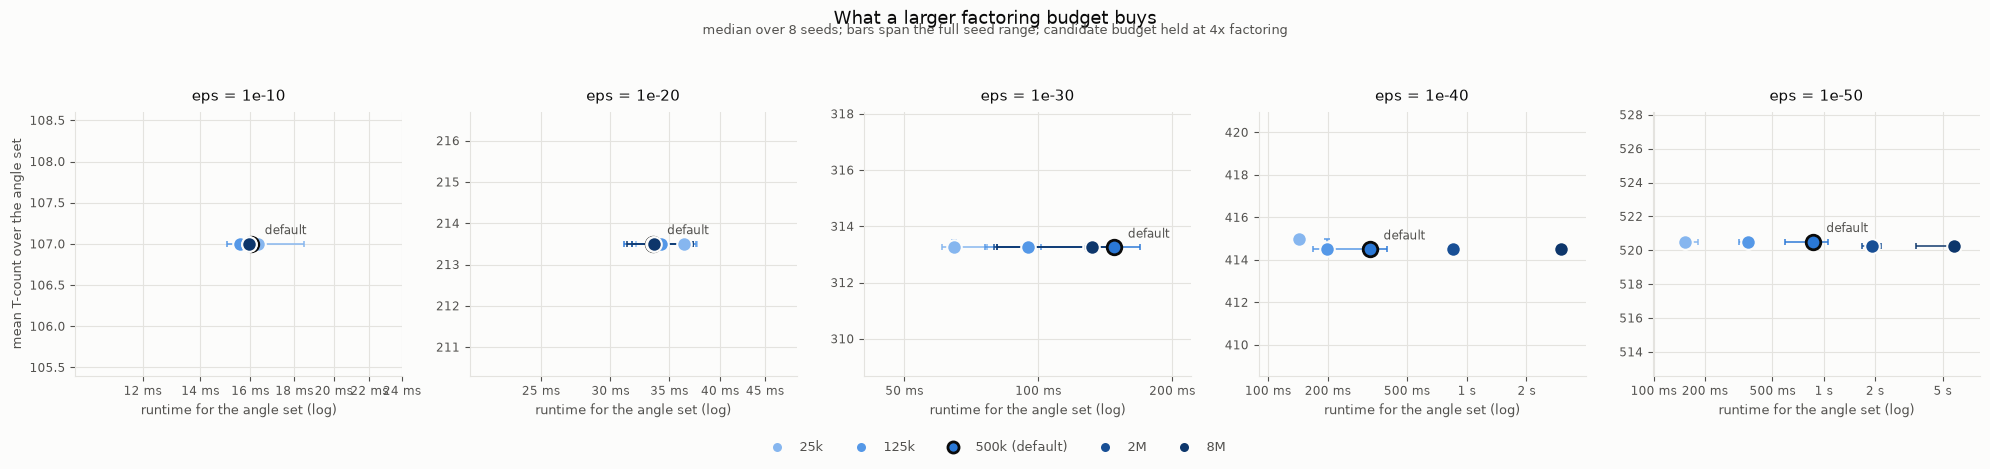

In [4]:
# Ordinal ramp: budget is ordered magnitude, not identity, so it gets one hue
# stepped light-to-dark rather than five competing colours. Steps validated for
# monotone lightness, visible gaps, and 2:1 contrast against the surface.
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95", "#0d366b"]
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e4e3df"

def ramp_for(settings):
    """One ramp step per setting, in the settings' own (ascending) order."""
    return {label: RAMP[i] for i, (label, _, _) in enumerate(settings)}


def tradeoff_figure(summary, settings, default_label, title, subtitle):
    """Colours and the marked default come from the arguments, not globals, so
    the two sweeps below cannot quietly repaint each other's figure."""
    color = ramp_for(settings)
    fig, axes = plt.subplots(1, len(EPSILONS),
                             figsize=(4.0 * len(EPSILONS), 4.4))
    fig.patch.set_facecolor(SURFACE)

    for ax, epsilon in zip(axes, EPSILONS):
        ax.set_facecolor(SURFACE)
        ax.set_xscale("log")
        for label, _, _ in settings:
            cell = summary[(epsilon, label)]
            if cell["t_med"] is None:
                continue
            is_default = label == default_label
            ax.errorbar(
                cell["seconds_med"], cell["t_med"],
                xerr=[[cell["seconds_med"] - cell["seconds_lo"]],
                      [cell["seconds_hi"] - cell["seconds_med"]]],
                yerr=[[cell["t_med"] - cell["t_lo"]],
                      [cell["t_hi"] - cell["t_med"]]],
                fmt="none", ecolor=color[label], elinewidth=1.2, capsize=2.5,
                capthick=1.2, alpha=0.9, zorder=2)
            ax.scatter([cell["seconds_med"]], [cell["t_med"]], s=110,
                       color=color[label], zorder=3,
                       edgecolor=INK if is_default else SURFACE,
                       linewidth=2.0 if is_default else 1.5)

        # One annotation per panel, on the default. Five ordinal steps are
        # what the legend is for; labelling more of them here just produces
        # overlapping text on the panels where the points sit close together.
        cell = summary[(epsilon, default_label)]
        if cell["t_med"] is not None:
            ax.annotate("default", (cell["seconds_med"], cell["t_med"]),
                        textcoords="offset points", xytext=(10, 7),
                        fontsize=8.5, color=INK_SOFT)

        # T-count differences here are fractions of a gate. Letting matplotlib
        # autoscale would zoom into a 0.25-gate window and draw a negligible
        # difference as a cliff, so hold the window to at least +/-1.5% of the
        # median -- a flat row then reads as flat.
        centres = [summary[(epsilon, l)]["t_med"] for l, _, _ in settings
                   if summary[(epsilon, l)]["t_med"] is not None]
        los = [summary[(epsilon, l)]["t_lo"] for l, _, _ in settings
               if summary[(epsilon, l)]["t_lo"] is not None]
        his = [summary[(epsilon, l)]["t_hi"] for l, _, _ in settings
               if summary[(epsilon, l)]["t_hi"] is not None]
        if centres:
            mid = (max(his) + min(los)) / 2
            half = max(0.015 * mid, (max(his) - min(los)) * 0.75, 1.0)
            ax.set_ylim(mid - half, mid + half)

        # Pad the log x-range so a panel whose points nearly coincide still
        # gets more than one labelled tick.
        xs = ([summary[(epsilon, l)]["seconds_lo"] for l, _, _ in settings] +
              [summary[(epsilon, l)]["seconds_hi"] for l, _, _ in settings])
        ax.set_xlim(min(xs) / 1.5, max(xs) * 1.3)

        ax.set_title(f"eps = {epsilon}", fontsize=11, color=INK, pad=8)
        ax.set_xlabel("runtime for the angle set (log)", fontsize=9,
                      color=INK_SOFT)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(GRID)
        ax.tick_params(colors=INK_SOFT, labelsize=8.5)
        # The default log ticking labels every minor tick and the labels
        # collide. Tick on 1/2/5 per decade instead, and read out sub-second
        # values in ms so the axis does not need scientific notation.
        ax.xaxis.set_major_locator(
            mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0), numticks=12))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v * 1000:g} ms" if v < 1 else f"{v:g} s"))

    axes[0].set_ylabel("mean T-count over the angle set", fontsize=9,
                       color=INK_SOFT)

    handles = [
        plt.Line2D([], [], marker="o", linestyle="", markersize=8,
                   markerfacecolor=color[label],
                   markeredgecolor=INK if label == default_label else SURFACE,
                   markeredgewidth=2.0 if label == default_label else 1.5,
                   label=label + (" (default)" if label == default_label else ""))
        for label, _, _ in settings
    ]
    legend = fig.legend(handles=handles, loc="lower center", ncol=len(settings),
                        frameon=False, fontsize=9,
                        bbox_to_anchor=(0.5, -0.015))
    for text in legend.get_texts():
        text.set_color(INK_SOFT)

    fig.suptitle(title, fontsize=13, color=INK, x=0.5, y=1.02)
    fig.text(0.5, 0.965, subtitle, ha="center", fontsize=9.5, color=INK_SOFT)
    fig.tight_layout(rect=[0, 0.06, 1, 0.95])
    return fig


fig = tradeoff_figure(
    summary, BUDGET_SETTINGS, budget_label(DEFAULT_FACTORING),
    "What a larger factoring budget buys",
    "median over 8 seeds; bars span the full seed range; "
    "candidate budget held at 4x factoring")
plt.show()

## The same numbers as a table

The plot shows the shape; this shows the values, including the two columns the
plot cannot: how many candidate solves each budget abandoned because it ran out
(`exhausted`), and how many calls failed outright.

In [5]:
def print_table(summary, settings, column="budget"):
    header = (f"{'eps':>7s}  {column:>7s}  {'runtime s':>10s}  "
              f"{'range':>15s}  {'mean T':>8s}  {'range':>13s}  "
              f"{'exhausted':>9s}  {'failed':>6s}")
    print(header)
    print("-" * len(header))
    for epsilon in EPSILONS:
        for label, _, _ in settings:
            c = summary[(epsilon, label)]
            if c["t_med"] is None:
                print(f"{epsilon:>7s}  {label:>7s}  {'--':>10s}"
                      f"  {'':>15s}  {'--':>8s}  {'':>13s}"
                      f"  {c['exhausted']:>9d}  {c['failures']:>6d}")
                continue
            print(f"{epsilon:>7s}  {label:>7s}  {c['seconds_med']:>10.3f}"
                  f"  {c['seconds_lo']:>6.3f}-{c['seconds_hi']:<8.3f}"
                  f"  {c['t_med']:>8.1f}"
                  f"  {c['t_lo']:>5.1f}-{c['t_hi']:<7.1f}"
                  f"  {c['exhausted']:>9d}  {c['failures']:>6d}")
        print()


print_table(summary, BUDGET_SETTINGS)

    eps   budget   runtime s            range    mean T          range  exhausted  failed
-----------------------------------------------------------------------------------------
  1e-10      25k       0.016   0.016-0.018        107.0  107.0-107.0            0       0
  1e-10     125k       0.016   0.015-0.016        107.0  107.0-107.0            0       0
  1e-10     500k       0.016   0.016-0.016        107.0  107.0-107.0            0       0
  1e-10       2M       0.016   0.015-0.016        107.0  107.0-107.0            0       0
  1e-10       8M       0.016   0.016-0.016        107.0  107.0-107.0            0       0

  1e-20      25k       0.036   0.032-0.038        213.5  213.5-213.5            4       0
  1e-20     125k       0.034   0.032-0.038        213.5  213.5-213.5            0       0
  1e-20     500k       0.034   0.031-0.037        213.5  213.5-213.5            0       0
  1e-20       2M       0.034   0.032-0.037        213.5  213.5-213.5            0       0
  1e-20  

## Sweeping the candidate budget separately

The sweep above moved both budgets together on the shipped 4:1 ratio, which
only explores a line through a two-dimensional space. This holds
`max_factoring_iterations` at the default and varies the multiplier, which
answers a different question: once a per-attempt budget is in place, does
letting a candidate make *more* attempts buy anything?

sweeping the candidate multiplier at the default factoring budget
          x1 done  (320/1600, 5s elapsed)
          x2 done  (640/1600, 13s elapsed)
          x4 done  (960/1600, 24s elapsed)
          x8 done  (1280/1600, 41s elapsed)
         x16 done  (1600/1600, 61s elapsed)


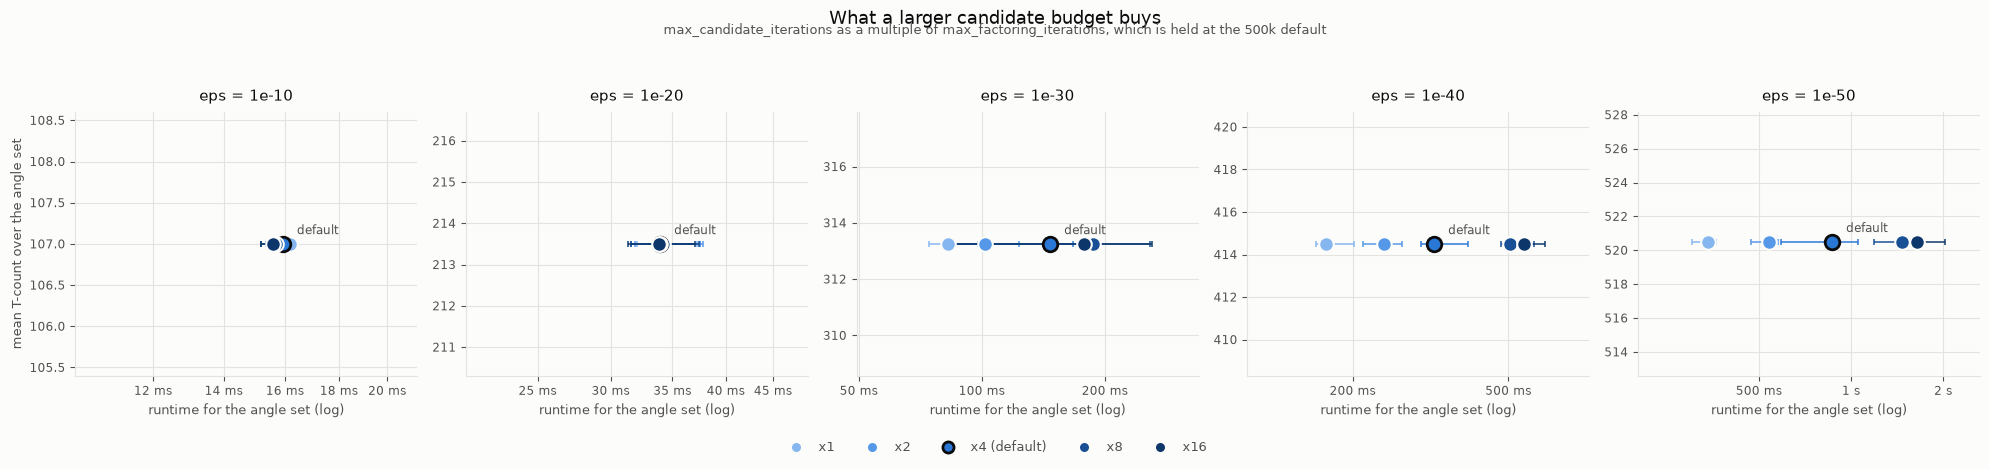

    eps    ratio   runtime s            range    mean T          range  exhausted  failed
-----------------------------------------------------------------------------------------
  1e-10       x1       0.016   0.016-0.016        107.0  107.0-107.0            0       0
  1e-10       x2       0.016   0.015-0.016        107.0  107.0-107.0            0       0
  1e-10       x4       0.016   0.015-0.016        107.0  107.0-107.0            0       0
  1e-10       x8       0.016   0.015-0.016        107.0  107.0-107.0            0       0
  1e-10      x16       0.016   0.015-0.016        107.0  107.0-107.0            0       0

  1e-20       x1       0.034   0.032-0.037        213.5  213.5-213.5            0       0
  1e-20       x2       0.034   0.032-0.038        213.5  213.5-213.5            0       0
  1e-20       x4       0.034   0.032-0.037        213.5  213.5-213.5            0       0
  1e-20       x8       0.034   0.032-0.037        213.5  213.5-213.5            0       0
  1e-20  

In [6]:
RATIO_SETTINGS = [(f"x{r}", DEFAULT_FACTORING, r * DEFAULT_FACTORING)
                  for r in (1, 2, 4, 8, 16)]

print("sweeping the candidate multiplier at the default factoring budget")
ratio_records = run_sweep(RATIO_SETTINGS)
ratio_summary = summarize(replicates(ratio_records), RATIO_SETTINGS)

fig = tradeoff_figure(
    ratio_summary, RATIO_SETTINGS, f"x{CANDIDATE_RATIO}",
    "What a larger candidate budget buys",
    "max_candidate_iterations as a multiple of max_factoring_iterations, "
    "which is held at the 500k default")
plt.show()

print_table(ratio_summary, RATIO_SETTINGS, column="ratio")

## Failures and budget exhaustion

Everything the sweep could not complete, and every place a budget actually
bound. A budget that never appears here is not buying anything on this corpus;
one that appears constantly is abandoning candidates and paying for it in T
gates.

In [7]:
def report_problems(all_records):
    failures = [r for r in all_records if r["failed"]]
    if failures:
        print(f"{len(failures)} failed call(s):")
        for r in failures:
            print(f"  {r['epsilon']} {r['angle']} budget={r['setting']} "
                  f"seed={r['seed']} after {r['seconds']:.2f}s: {r['reason']}")
    else:
        print("no failures: every call returned a circuit")

    # The guard clock must never be what ended a run, or the numbers above are
    # host-dependent rather than reproducible.
    timed_out = [r for r in failures if "timeout_ms expired" in (r["reason"] or "")]
    print(f"\nguard timeout fired on {len(timed_out)} call(s) "
          f"(must be 0 for these numbers to transfer between machines)")

    print("\nbudget exhaustion by tolerance and setting "
          "(candidate solves abandoned because a budget ran out):")
    by_cell = defaultdict(int)
    for r in all_records:
        if not r["failed"]:
            by_cell[(r["epsilon"], r["setting"])] += r["budget_exhausted"]
    for epsilon in EPSILONS:
        row = {k[1]: v for k, v in by_cell.items() if k[0] == epsilon}
        if any(row.values()):
            cells = "  ".join(f"{k}={v}" for k, v in row.items() if v)
            print(f"  {epsilon:>7s}  {cells}")
        else:
            print(f"  {epsilon:>7s}  none -- every candidate ran to a verdict")


report_problems(records + ratio_records)

no failures: every call returned a circuit

guard timeout fired on 0 call(s) (must be 0 for these numbers to transfer between machines)

budget exhaustion by tolerance and setting (candidate solves abandoned because a budget ran out):
    1e-10  none -- every candidate ran to a verdict
    1e-20  25k=4
    1e-30  25k=28  125k=11  500k=6  x1=6  x2=6  x4=6  x8=1  x16=1
    1e-40  25k=70  125k=18  500k=9  2M=8  8M=8  x1=14  x2=11  x4=9  x8=8  x16=8
    1e-50  25k=66  125k=46  500k=32  2M=15  8M=12  x1=38  x2=33  x4=32  x8=29  x16=31


## What this says about the defaults

The measured shape, reading the panels left to right:

**Above 1e-30 the knob is inert.** Every budget lands on the same point with
identical T-count, and nothing exhausts. Whatever the default is, it cannot be
wrong at these tolerances, and the exposure exists for the deep end only.

**At the deep end runtime rises steeply and T-count does not follow.** From 25k
to 8M at `1e-40`, runtime goes 0.14s to 3.0s -- a factor of 21 -- while mean
T-count moves from 415.0 to 414.5. That half-gate is one angle out of eight
coming out 4 gates shorter; the other seven are identical. `1e-50` is the same
story at a factor of 39 for 0.3 mean gates.

**The candidate multiplier buys nothing.** The second sweep is flat in
T-count at every tolerance -- 414.5 across the whole row at `1e-40`, 520.5 at
`1e-50` -- while runtime triples from x1 to x16. So the 4:1 ratio is not what
makes the defaults work, and the per-attempt budget is the constraint that
actually binds. That matches what exhaustion says: at `1e-40` the multiplier
moves exhausted candidates only 14 to 8, and it never reaches zero because
past a point it is the restart limit firing, not the iteration budget.

**Seed spread is small relative to the effect.** The bars are visibly narrower
than the gaps between budgets at the deep end, so the ordering above is not an
artifact of which seed was drawn -- which is the whole reason for fixing a seed
and running eight of them.

### What that argues

On this angle set the shipped 500k default is **conservative**: it costs about
2.3x the runtime of 25k at `1e-40` to buy half a T gate on average. A smaller
per-attempt budget would be defensible here, and a smaller candidate multiplier
looks free.

The caution, stated plainly so this is not over-read: **eight angles are not the
corpus.** The full 908-case corpus is where a default should be set, and it
contains inputs harder than any of these -- the argument for a conservative
budget is precisely about cases this set does not contain, which is exactly the
kind of claim eight angles cannot settle. What this notebook establishes is the
*shape* of the tradeoff and where it lives: monotone in runtime, nearly flat in
T-count, entirely below 1e-30, and driven by the per-attempt budget rather than
the ratio. Any default has to be argued on that shape.